In [1]:
# Import packages and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [2]:
# Check the version of XGBoost
print("Found XGBoost v" + xgboost.__version__)

Found XGBoost v2.1.4


In [3]:
datasetPath = "dataset/10p/all/kernel3/"

In [4]:
# Parameters
datasetPath = "dataset/mask5/10p/ngtdm/kernel4/"


In [5]:
# train/validation/test = 70/10/20
train_data = pd.read_csv(f"{datasetPath}dataset.train.csv")
validation_data = pd.read_csv(f"{datasetPath}dataset.validation.csv")
test_data = pd.read_csv(f"{datasetPath}dataset.test.csv")

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights on the training set
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_data["label"]
)
class_weight = dict(zip(classes, weights))

# Prepare features and sample weights for XGBoost
feature_cols = [
    col for col in train_data.columns
    if col not in ["label", "sample_weight"]
]
X_train = train_data[feature_cols]
y_train = train_data["label"].astype(int)
X_val = validation_data[feature_cols]
y_val = validation_data["label"].astype(int)
X_test = test_data[feature_cols]
y_test = test_data["label"].astype(int)

train_weight = y_train.map(class_weight).to_numpy()
val_weight = y_val.map(class_weight).to_numpy()
test_weight = y_test.map(class_weight).to_numpy()

In [7]:
# XGBClassifier uses the pandas data prepared above

In [8]:
%%time

# Train an XGBoost binary classification model.
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    sample_weight=train_weight,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    sample_weight_eval_set=[train_weight, val_weight],
    verbose=False
)

CPU times: user 5.8 s, sys: 52.7 ms, total: 5.85 s
Wall time: 620 ms


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['logloss', 'auc'],
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [9]:
# Evaluate the model on the validation set
from sklearn.metrics import accuracy_score, roc_auc_score

val_probs = model.predict_proba(X_val)[:, 1]
val_pred = (val_probs >= 0.5).astype(int)

print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Validation ROC AUC: {roc_auc_score(y_val, val_probs):.4f}")

Validation accuracy: 0.9749
Validation ROC AUC: 0.9798


In [10]:
# Model summary
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['logloss', 'auc'],
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)


In [11]:
# Model features
feature_cols

['Busyness', 'Coarseness', 'Complexity', 'Contrast', 'Strength']

Busyness      0.367330
Coarseness    0.193083
Complexity    0.158885
Strength      0.148910
Contrast      0.131792
dtype: float32


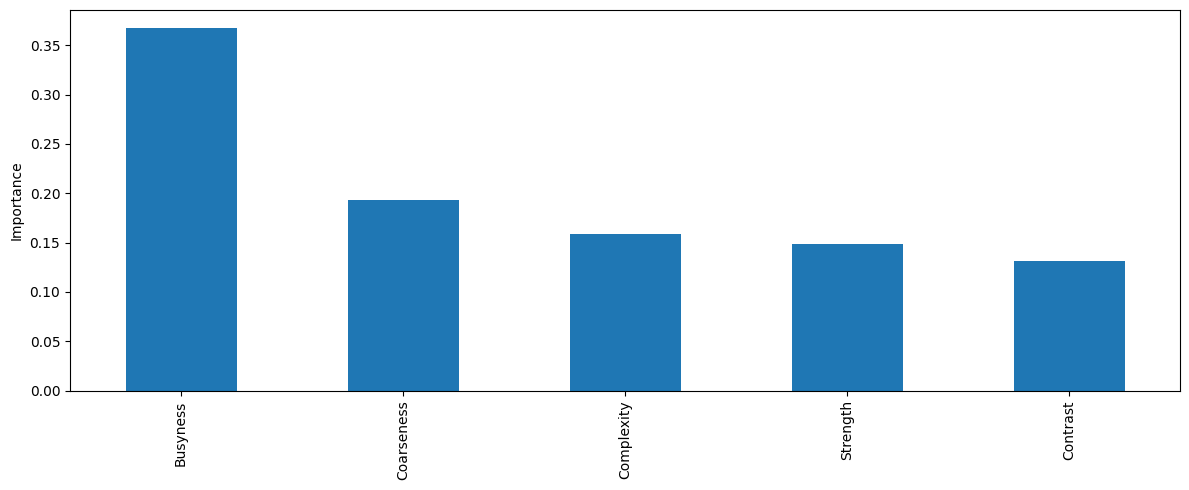

In [12]:
# Feature importance
feature_importance = (
    pd.Series(model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)

print(feature_importance.head(20))
feature_importance.head(20).plot.bar(figsize=(12, 5))
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [13]:
# Model attributes
model.get_booster().attributes()

{}

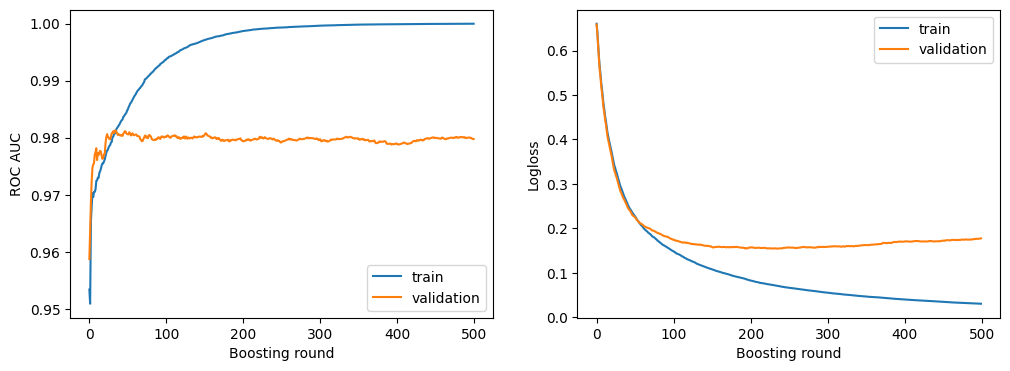

In [14]:
results = model.evals_result()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(results["validation_0"]["auc"], label="train")
plt.plot(results["validation_1"]["auc"], label="validation")
plt.xlabel("Boosting round")
plt.ylabel("ROC AUC")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="validation")
plt.xlabel("Boosting round")
plt.ylabel("Logloss")
plt.legend()
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict_proba(X_val)[:, 1]
y_true = y_val

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC)

The ROC AUC score is 0.97976


In [16]:
# Compute binary classification metrics with sklearn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get positive-class probabilities and convert them to labels
pos_probs = model.predict_proba(X_test)[:, 1]
y_pred = (pos_probs >= 0.5).astype(int)
y_true = y_test.to_numpy()

metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)
metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0, 1])
metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

Sklearn binary metrics:
accuracy: 0.9606
precision: 0.8703
recall: 0.7093
f1: 0.7816
mcc: 0.7649
roc_auc: 0.9536
pr_auc: 0.8305
log_loss: 0.1315
brier_score: 0.0328

Confusion matrix:
 [[2032   24]
 [  66  161]]

Classification report:
               precision    recall  f1-score   support

           0     0.9685    0.9883    0.9783      2056
           1     0.8703    0.7093    0.7816       227

    accuracy                         0.9606      2283
   macro avg     0.9194    0.8488    0.8799      2283
weighted avg     0.9588    0.9606    0.9588      2283

